# WhatsApp Chat Analysis

## Objective
This project analyzes WhatsApp chat data to uncover communication patterns, user activity, message trends, media-sharing behavior, and emoji usage.

### Key Analyses
- User activity analysis
- Daily and monthly timelines
- Activity heatmaps
- Word cloud generation
- Emoji analysis
- Media sharing analysis

## 1. Data Loading and Preprocessing

The WhatsApp exported chat file is loaded and parsed using regular expressions.
The extracted information includes:
- Timestamp
- User name
- Message content

The timestamps are then converted into datetime format and additional temporal features are created.

In [1]:
import pandas as pd
import re
with open('_study.txt', 'r', encoding='utf-8') as f:
    data = f.read()
pattern = r'(\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}(?:\s?[APMapm]{2})?)\s-\s(.*?):\s(.*)'
matches = re.findall(pattern, data)
dates = []
users = []
messages = []
for match in matches:    
    dates.append(match[0])
    users.append(match[1])
    messages.append(match[2])
df = pd.DataFrame({
    'datetime': dates,
    'user': users,
    'message': messages
})

df['datetime'] = (
    df['datetime']
    .str.replace('\u202f', ' ', regex=False)
    .str.strip()
)

df['datetime'] = pd.to_datetime(
    df['datetime'],
    format='mixed'
)
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day

df['hour'] = df['datetime'].dt.hour
df['minute'] = df['datetime'].dt.minute

df['month_name'] = df['datetime'].dt.month_name()
df['day_name'] = df['datetime'].dt.day_name()

df['date'] = df['datetime'].dt.date
df['time'] = df['datetime'].dt.time



## 2. Active User Analysis

This section identifies the most active participants in the conversation by calculating the percentage contribution of messages from each user.

In [2]:
print((df['user'].value_counts().head(5)/df.shape[0])*100)

user
+91 77109 32568    15.724678
+91 99872 19482    14.101847
+91 91754 16601    10.296586
+91 80976 26564     7.442641
+91 84228 22435     5.540011
Name: count, dtype: float64


## 3. Daily Timeline Analysis

The number of messages sent each day is calculated and visualized to identify communication trends over time.

(array([20513., 20527., 20544., 20558., 20574., 20588., 20605.]),
 [Text(20513.0, 0, '2026-03-01'),
  Text(20527.0, 0, '2026-03-15'),
  Text(20544.0, 0, '2026-04-01'),
  Text(20558.0, 0, '2026-04-15'),
  Text(20574.0, 0, '2026-05-01'),
  Text(20588.0, 0, '2026-05-15'),
  Text(20605.0, 0, '2026-06-01')])

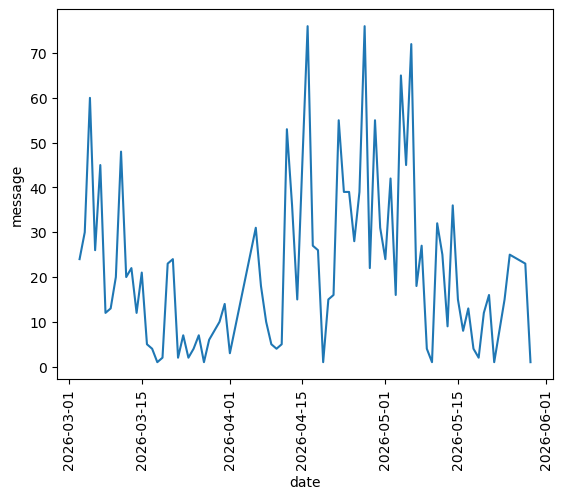

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

daily = df.groupby('date').count()['message']
sns.lineplot(data=daily)
plt.xticks(rotation='vertical')


## 4. Monthly Timeline Analysis

Messages are aggregated monthly to observe long-term communication patterns and seasonal variations.

In [4]:
monthly_timeline = df.groupby(
    ['year', 'month_name']
).count()['message'].reset_index()


<Axes: xlabel='month_name', ylabel='message'>

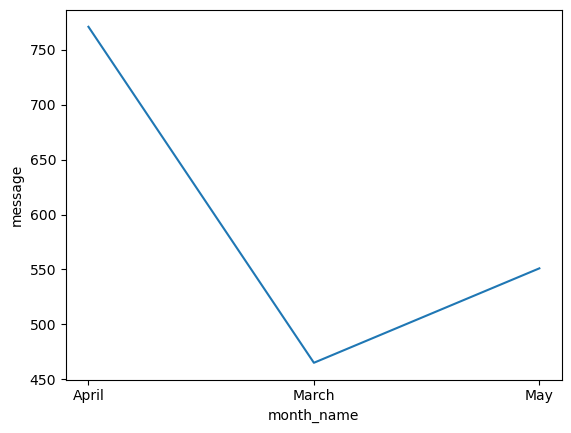

In [5]:
sns.lineplot(data=monthly_timeline,x='month_name',y='message')

In [6]:
pivot = df.pivot_table(
    index='day_name',
    columns='hour',
    values='message',
    aggfunc='count'
)
pivot

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_name,,,,,,,,,,,,,,,,,,,,,
Friday,NaN,NaN,1.0,NaN,NaN,NaN,NaN,7.0,23.0,5.0,...,20.0,21.0,2.0,3.0,2.0,42.0,8.0,5.0,6.0,7.0
Monday,7.0,22.0,NaN,NaN,NaN,1.0,NaN,NaN,5.0,11.0,...,34.0,38.0,10.0,26.0,39.0,16.0,19.0,14.0,5.0,3.0
Saturday,7.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,5.0,27.0,...,7.0,1.0,5.0,22.0,5.0,12.0,29.0,15.0,8.0,10.0
Sunday,NaN,NaN,NaN,NaN,3.0,3.0,1.0,NaN,NaN,NaN,...,1.0,NaN,1.0,4.0,35.0,36.0,19.0,5.0,9.0,31.0
Thursday,24.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,20.0,21.0,...,14.0,9.0,10.0,7.0,13.0,33.0,37.0,50.0,15.0,10.0
Tuesday,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.0,...,28.0,3.0,6.0,10.0,14.0,6.0,5.0,5.0,11.0,6.0
Wednesday,4.0,2.0,NaN,NaN,4.0,3.0,3.0,NaN,6.0,22.0,...,10.0,9.0,7.0,5.0,17.0,20.0,10.0,20.0,31.0,46.0


In [7]:
days = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

pivot = pivot.reindex(days)

## 5. Activity Heatmap

A heatmap is created to visualize message activity across different days of the week and hours of the day.

Insights:
- Peak activity periods
- Most active weekdays
- Preferred communication times

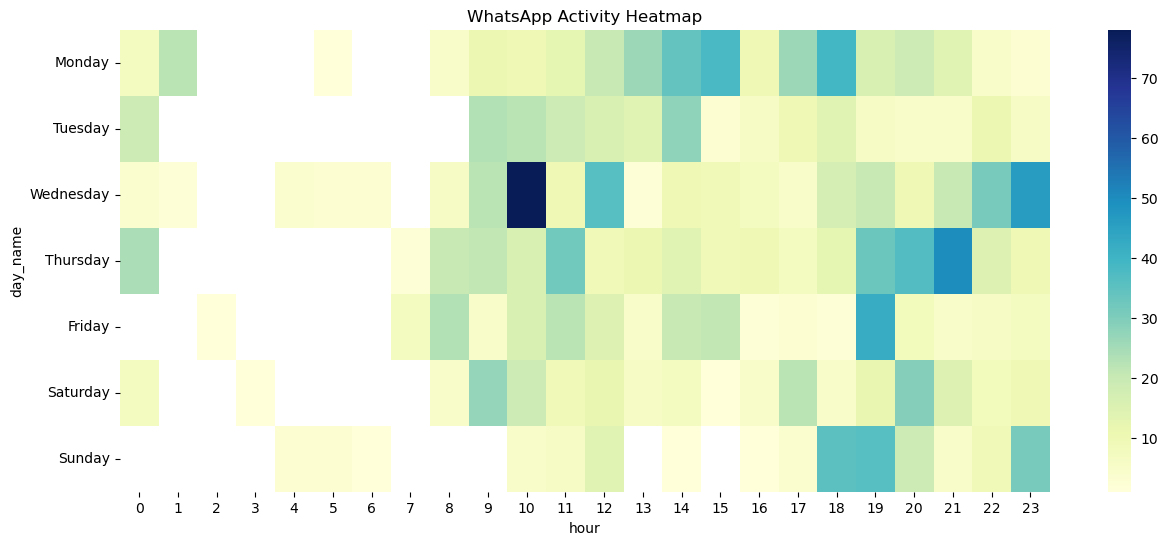

In [8]:
plt.figure(figsize=(15,6))

sns.heatmap(
    pivot,
    cmap='YlGnBu'
)

plt.title("WhatsApp Activity Heatmap")

plt.show()

## 6. Word Cloud Analysis

A word cloud is generated from all messages to highlight the most frequently used words in the conversation.

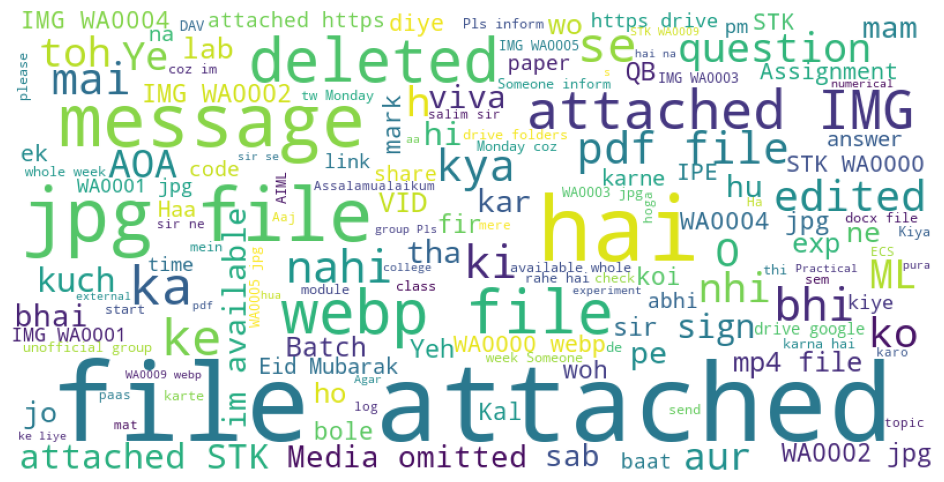

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all messages into one string
text = " ".join(df['message'])

# Create WordCloud object
wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    min_font_size=10
)

# Generate word cloud
wordcloud = wc.generate(text)

# Plot
plt.figure(figsize=(15,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

## 7. Emoji Analysis

Emojis are extracted from messages and ranked according to usage frequency.

Purpose:
- Understand emotional expression
- Identify commonly used reactions

In [10]:
import emoji

emojis = []

for msg in df['message']:
    
    for c in msg:
        
        if c in emoji.EMOJI_DATA:
            emojis.append(c)
from collections import Counter

Counter(emojis).most_common(10)

[('✨', 19),
 ('😭', 13),
 ('🔥', 9),
 ('🤧', 7),
 ('🫶', 5),
 ('🥲', 5),
 ('🏻', 5),
 ('🥹', 5),
 ('😅', 5),
 ('🌈', 5)]

## 8. User-Specific Analysis

A detailed analysis is performed for a selected user.

Metrics analyzed:
- Monthly activity
- Activity heatmap
- Most frequently used words

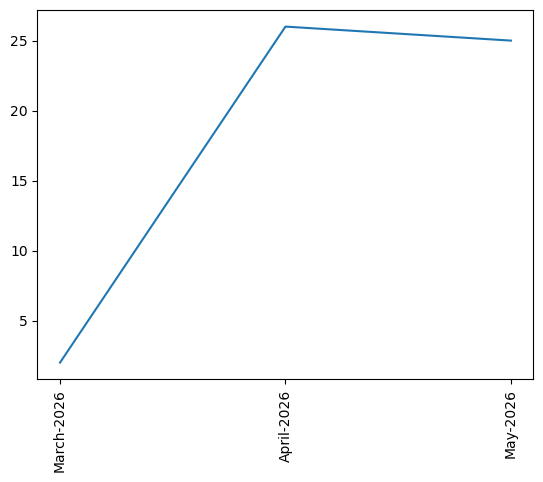

In [11]:
selected_user = '<user>'

user_df = df[df['user'] == selected_user]
monthly_timeline = user_df.groupby(
    ['year','month','month_name']
).count()['message'].reset_index()

monthly_timeline['time'] = (
    monthly_timeline['month_name']
    + "-"
    + monthly_timeline['year'].astype(str)
)
import matplotlib.pyplot as plt

plt.plot(
    monthly_timeline['time'],
    monthly_timeline['message']
)

plt.xticks(rotation='vertical')

plt.show()

In [12]:
pivot = user_df.pivot_table(
    index='day_name',
    columns='hour',
    values='message',
    aggfunc='count'
)

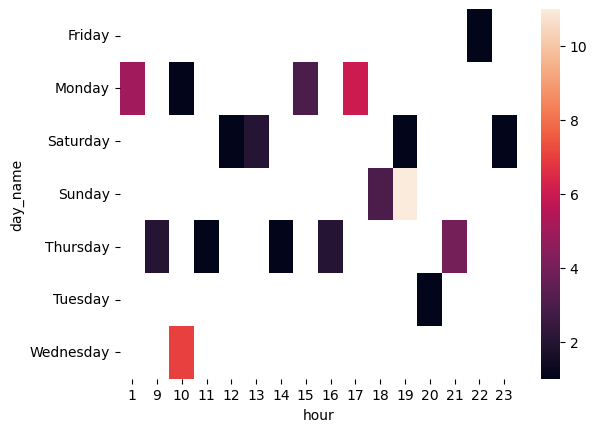

In [13]:
import seaborn as sns

sns.heatmap(pivot)

plt.show()

In [14]:
words = []

for message in user_df['message']:
    words.extend(message.split())

from collections import Counter

Counter(words).most_common(20)

[('hai', 18),
 ('bhi', 6),
 ('mein', 6),
 ('nhi', 5),
 ('toh', 5),
 ('ki', 5),
 ('ho', 4),
 ('ka', 4),
 ('Haa', 4),
 ('ko', 4),
 ('sir', 4),
 ('message', 4),
 ('aur', 4),
 ('ke', 4),
 ('se', 3),
 ('kro', 3),
 ('paas', 3),
 ('You', 3),
 ('deleted', 3),
 ('this', 3)]

## 9. Media Detection and Classification

Media messages are identified using pattern matching.

Supported media types:
- Images
- Videos
- Audio files
- Documents
- GIFs

In [15]:
import re

# Detect media messages (works for both export types)
# "with media" export: filename.jpg (file attached)
# "without media" export: <Media omitted>

media_pattern = re.compile(
    r'<[Mm]edia omitted>|'
    r'\S+\.(jpg|jpeg|png|mp4|mkv|opus|mp3|aac|pdf|docx|gif|webp)\s*\(file attached\)',
    re.IGNORECASE
)

df['is_media'] = df['message'].str.contains(media_pattern)

# Media type classifier
def get_media_type(msg):
    msg = msg.lower()
    if re.search(r'\.(jpg|jpeg|png|gif|webp)', msg):
        return 'Image'
    elif re.search(r'\.(mp4|mkv|avi)', msg):
        return 'Video'
    elif re.search(r'\.(opus|mp3|aac)', msg):
        return 'Audio'
    elif re.search(r'\.(pdf|docx|txt|xlsx)', msg):
        return 'Document'
    elif '<media omitted>' in msg:
        return 'Unknown (omitted)'
    return None

df['media_type'] = df['message'].apply(
    lambda m: get_media_type(m) if media_pattern.search(m) else None
)

print("Total media messages:", df['is_media'].sum())
print("\nMedia type breakdown:")
print(df['media_type'].value_counts())

Total media messages: 322

Media type breakdown:
media_type
Image                225
Document              55
Unknown (omitted)     22
Video                 20
Name: count, dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7420\2890754680.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['is_media'] = df['message'].str.contains(media_pattern)


## 10. Top Media Contributors

This analysis identifies users who share the highest amount of media content within the chat.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7420\313772952.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=media_per_user.head(10), x='Media Count', y='User', palette='magma')


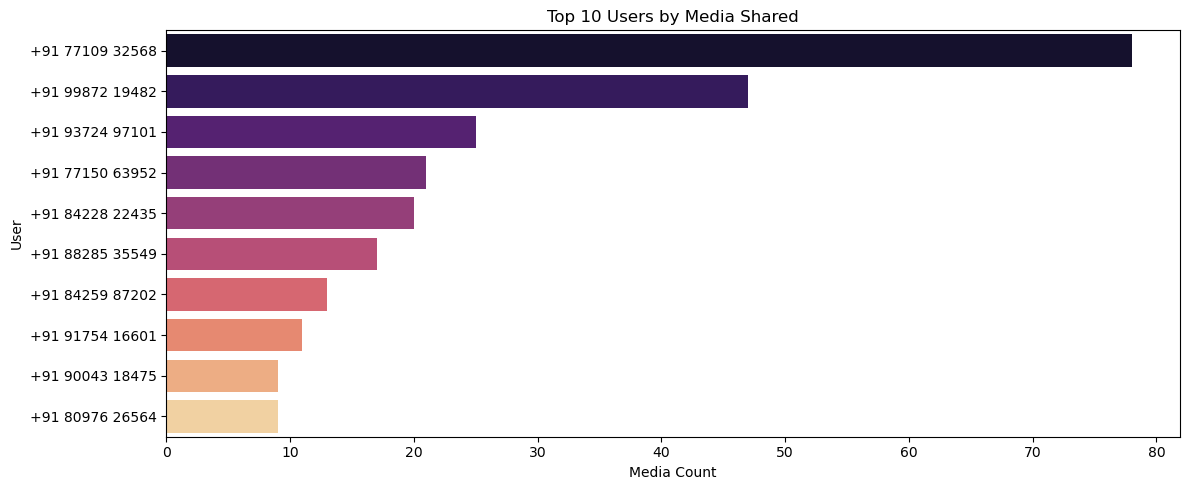

In [16]:
media_df = df[df['is_media'] == True]

media_per_user = media_df['user'].value_counts().reset_index()
media_per_user.columns = ['User', 'Media Count']

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.barplot(data=media_per_user.head(10), x='Media Count', y='User', palette='magma')
plt.title('Top 10 Users by Media Shared')
plt.tight_layout()
plt.show()

## 11. Media Type Distribution

A pie chart visualizes the proportion of different media types shared in the conversation.

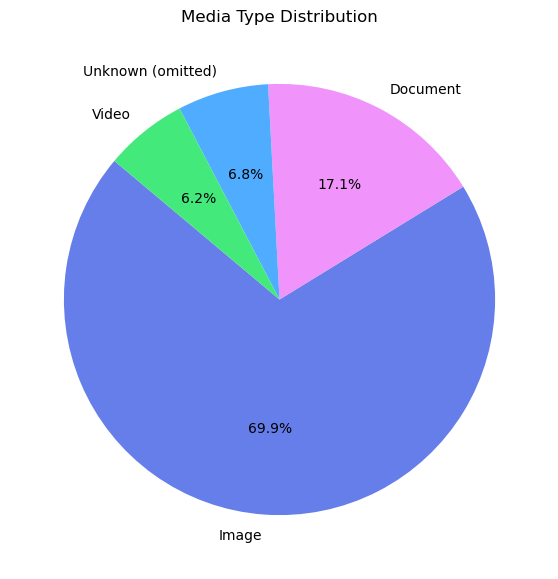

In [17]:
type_counts = df['media_type'].value_counts().dropna()

plt.figure(figsize=(7, 7))
plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#667eea', '#f093fb', '#4facfe', '#43e97b', '#fa709a']
)
plt.title('Media Type Distribution')
plt.show()

## 12. Media Sharing Timeline

Media activity is analyzed over time to identify periods of increased sharing.

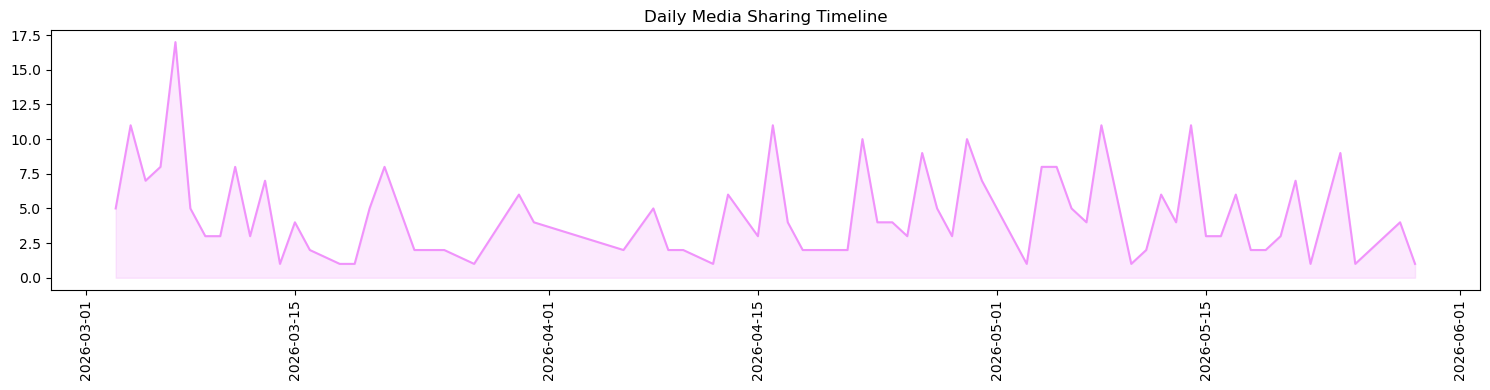

In [18]:
media_daily = media_df.groupby('date')['message'].count().reset_index()
media_daily.columns = ['Date', 'Media Messages']

plt.figure(figsize=(15, 4))
plt.plot(media_daily['Date'], media_daily['Media Messages'], color='#f093fb', linewidth=1.5)
plt.fill_between(media_daily['Date'], media_daily['Media Messages'], alpha=0.2, color='#f093fb')
plt.title('Daily Media Sharing Timeline')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 13. Media Sharing Heatmap

This heatmap shows how media sharing varies across weekdays and hours.

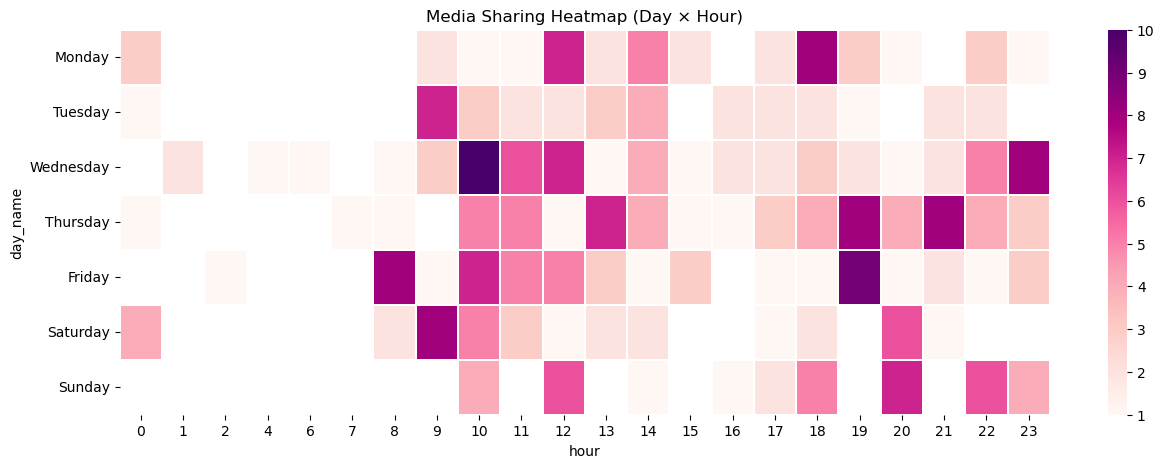

In [19]:
media_pivot = media_df.pivot_table(
    index='day_name',
    columns='hour',
    values='message',
    aggfunc='count'
).reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(15, 5))
sns.heatmap(media_pivot, cmap='RdPu', linewidths=0.3)
plt.title('Media Sharing Heatmap (Day × Hour)')
plt.show()

In [20]:
selected_user = 'Shaikh Salahuddin'  # change as needed

user_media = df[(df['user'] == selected_user) & (df['is_media'] == True)]

print(f"=== Media Stats for {selected_user} ===")
print(f"Total media sent : {len(user_media)}")
print(f"% of their msgs  : {len(user_media)/len(df[df['user']==selected_user])*100:.1f}%")
print("\nBreakdown by type:")
print(user_media['media_type'].value_counts())

=== Media Stats for Shaikh Salahuddin ===
Total media sent : 1
% of their msgs  : 1.9%

Breakdown by type:
media_type
Image    1
Name: count, dtype: int64
